# H1 — Does the signal survive a longer holding period?

## The actual arithmetic

Net return per day on a k-day hold is `(G(k) − RT) / k`, where `G(k)` is the gross
top-minus-bottom spread over the whole holding period and `RT` is the round-trip cost.

At k=1 the research split gave `G(1) = 16.5 bp` against `RT = 12 bp`, so **+4.5 bp/day**.
For k=5 to beat that you need `G(5) > 12 + 4.5×5 = 34.5 bp` — the signal must keep
*accumulating* well past the first overnight, not merely survive.

So H1 is not "costs fall, therefore it works". It is a question about **signal decay**, and
the decay curve answers it before any model is fitted.

## Two traps this notebook handles

**Overlapping returns inflate t-statistics.** A k-day forward return measured every day
shares k−1 days with its neighbours. The naive t-statistic is roughly `√k` too large. Both
naive and Newey–West corrected values are reported; only the corrected one means anything.

**Training targets that extend into the test window leak.** With a k-day target, a training
row dated t−2 has an outcome that depends on prices at t+3. Training on it to predict day t
is look-ahead. Every fit here **purges** the last k sessions of the training window.

## Reads the sealed research split only

`panel_research.parquet` — 378 sessions to 2026-02-23. The 126-session holdout stays sealed.

In [1]:
# ============================ Cell 1 — Config and data
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)

CFG = {
    "panel": "ib_out/panel_research.parquet",   # sealed split; holdout untouched
    "earnings": "earnings_dates.csv",
    "horizons": [1, 2, 3, 5, 10],
    "round_trip_bp": 12.0,
    "earnings_blackout_days": 2,
    "min_train_sessions": 160,
    "refit_every_days": 21,
    "winsor": (0.005, 0.995),
    "decile_frac": 0.10,
    "min_names": 40,
    "inner_holdout": 63,
}

panel = pd.read_parquet(CFG["panel"])
panel["session"] = pd.to_datetime(panel["session"]).dt.normalize()
panel = panel.sort_values(["ticker", "session"]).reset_index(drop=True)
OPEN = "px_open_adj" if "px_open_adj" in panel.columns else "px_open"

earn = pd.read_csv(CFG["earnings"], parse_dates=["ann_date"])
earn["ticker"] = earn["ticker"].astype(str).str.split().str[0]
bl = CFG["earnings_blackout_days"]
flag = pd.concat([earn.assign(session=earn["ann_date"] + pd.Timedelta(days=k))[["ticker","session"]]
                  for k in range(-bl, bl+1)], ignore_index=True).drop_duplicates()
flag["is_earnings"] = True
panel = panel.merge(flag, on=["ticker","session"], how="left")
panel["is_earnings"] = panel["is_earnings"].fillna(False).astype(bool)

print(f"panel  : {panel.shape}, {panel['ticker'].nunique()} tickers, "
      f"{panel['session'].nunique()} sessions")
print(f"         {panel['session'].min().date()} -> {panel['session'].max().date()}")
print(f"open   : {OPEN}")
print(f"earnings-window rows: {panel['is_earnings'].mean():.2%}")

panel  : (55896, 18), 149 tickers, 378 sessions
         2024-08-19 -> 2026-02-20
open   : px_open_adj
earnings-window rows: 5.08%


In [2]:
# ============================ Cell 2 — Multi-horizon targets
# Enter at the 15:55 price on session t, exit at the opening auction k sessions later.
# Pivoting to a session x ticker grid keeps the shift on the true session calendar
# rather than on each ticker's own row order.
piv_open = panel.pivot(index="session", columns="ticker", values=OPEN)
piv_entry = panel.pivot(index="session", columns="ticker", values="entry_price")

targets = {}
for k in CFG["horizons"]:
    fwd = piv_open.shift(-k)
    t = (fwd / piv_entry - 1.0).stack().rename(f"y{k}")
    targets[k] = t

T = pd.concat(targets.values(), axis=1).reset_index()
panel = panel.merge(T, on=["session", "ticker"], how="left")

print("horizon   n obs      sd bp   mean bp")
for k in CFG["horizons"]:
    s = panel[f"y{k}"].dropna()
    print(f"{k:>7}  {len(s):>7,}  {s.std()*1e4:>8.0f}  {s.mean()*1e4:>8.2f}")
print("\nsd should scale roughly as sqrt(k) if returns are near-independent.")

horizon   n obs      sd bp   mean bp
      1   55,747       118      2.53
      2   55,598       228      8.00
      3   55,449       294     13.38
      5   55,151       400     23.93
     10   54,406       572     50.82

sd should scale roughly as sqrt(k) if returns are near-independent.


In [3]:
# ============================ Cell 3 — Signal decay, model-free
# Before fitting anything: does the raw signal predict day 2, 3, 4...? If the
# information is exhausted in the first overnight, no holding period can rescue it.
print("=" * 74)
print("SIGNAL DECAY — IC of each raw feature against the k-day forward return")
print("=" * 74)

for c in ["intraday_ret", "late_ret"]:
    if c not in panel.columns:
        panel[c] = np.nan
if panel["intraday_ret"].isna().all():
    panel["intraday_ret"] = panel["entry_price"] / panel[OPEN] - 1.0

rows = []
for k in CFG["horizons"]:
    r = {"horizon": k}
    for c in ["intraday_ret", "late_ret"]:
        ics = (panel.dropna(subset=[c, f"y{k}"])
                    .groupby("session")
                    .apply(lambda g: g[c].corr(g[f"y{k}"], method="spearman")
                           if len(g) >= CFG["min_names"] else np.nan)
                    .dropna())
        r[f"IC_{c}"] = ics.mean()
        r[f"t_{c}_naive"] = ics.mean() / ics.std() * np.sqrt(len(ics))
        r[f"t_{c}_NW"] = r[f"t_{c}_naive"] / np.sqrt(k)   # overlap correction
    rows.append(r)

decay = pd.DataFrame(rows).set_index("horizon")
display(decay.round(4))

print("\nMARGINAL information from each extra day held:")
for c in ["intraday_ret", "late_ret"]:
    ic = decay[f"IC_{c}"]
    print(f"  {c:<14} " + "  ".join(
        f"k={k}:{ic.loc[k]:+.4f}" for k in CFG["horizons"]))
print("\nIf |IC| is flat across k, the signal is exhausted in the first overnight and")
print("a longer hold only dilutes it. If |IC| grows with k, the effect persists.")

SIGNAL DECAY — IC of each raw feature against the k-day forward return


,IC_intraday_ret,t_intraday_ret_naive,t_intraday_ret_NW,IC_late_ret,t_late_ret_naive,t_late_ret_NW
horizon,,,,,,
1,-0.0569,-5.0470,-5.0470,-0.0608,-6.6683,-6.6683
2,-0.0160,-1.6365,-1.1572,-0.0250,-2.9215,-2.0658
3,-0.0157,-1.6394,-0.9465,-0.0186,-2.2039,-1.2724
5,-0.0140,-1.5148,-0.6774,-0.0133,-1.5513,-0.6937
10,-0.0107,-1.1143,-0.3524,-0.0063,-0.7456,-0.2358



MARGINAL information from each extra day held:
  intraday_ret   k=1:-0.0569  k=2:-0.0160  k=3:-0.0157  k=5:-0.0140  k=10:-0.0107
  late_ret       k=1:-0.0608  k=2:-0.0250  k=3:-0.0186  k=5:-0.0133  k=10:-0.0063

If |IC| is flat across k, the signal is exhausted in the first overnight and
a longer hold only dilutes it. If |IC| grows with k, the effect persists.


In [4]:
# ============================ Cell 4 — Features
df = panel.copy()
g = df.groupby("ticker")
df["prev_close"] = g["px_close"].shift(1)
df["prev_overnight"] = df[OPEN] / df["prev_close"] - 1.0
df["ret_1d"]  = g["entry_price"].pct_change(1, fill_method=None)
df["ret_5d"]  = g["entry_price"].pct_change(5, fill_method=None)
df["ret_20d"] = g["entry_price"].pct_change(20, fill_method=None)
df["ma20_gap"] = df["entry_price"] / g["entry_price"].transform(
    lambda s: s.rolling(20, min_periods=15).mean()) - 1.0
df["rv_20d"] = g["ret_1d"].transform(lambda s: s.rolling(20, min_periods=15).std()) * np.sqrt(252)
rng = (df["high_to_entry"] - df["low_to_entry"]).replace(0, np.nan)
df["range_pos"] = (df["entry_price"] - df["low_to_entry"]) / rng
df["vol_ratio"] = df["vol_to_entry"] / g["vol_to_entry"].transform(
    lambda s: s.rolling(20, min_periods=15).mean()).replace(0, np.nan)
for c in ["intraday_ret", "late_ret", "ret_5d"]:
    df[f"market_{c}"] = df.groupby("session")[c].transform("mean")
df["relative_intraday"] = df["intraday_ret"] - df["market_intraday_ret"]
df["relative_late"] = df["late_ret"] - df["market_late_ret"]

FEATURES = {
    "minimal": ["intraday_ret", "late_ret"],
    "core": ["intraday_ret", "late_ret", "relative_intraday", "relative_late",
             "prev_overnight", "ret_5d", "ret_20d", "ma20_gap", "rv_20d",
             "range_pos", "vol_ratio"],
}
df = df.replace([np.inf, -np.inf], np.nan)
for nm, cols in FEATURES.items():
    print(f"{nm:<10} {len(cols):>2} features, min coverage "
          f"{df[cols].notna().mean().min():.3f}")

minimal     2 features, min coverage 1.000
core       11 features, min coverage 0.947


In [5]:
# ============================ Cell 5 — Walk-forward with purging
def make_model():
    return HistGradientBoostingRegressor(
        loss="squared_error", learning_rate=0.045, max_iter=180,
        max_leaf_nodes=15, min_samples_leaf=80, l2_regularization=2.0,
        random_state=42)


def walk_forward(data, feats, k, label, verbose=True):
    ycol = f"y{k}"
    d = data.dropna(subset=list(feats) + [ycol]).copy()
    d["y_dm"] = d[ycol] - d.groupby("session")[ycol].transform("mean")
    sess = np.array(sorted(d["session"].unique()))
    parts, mdl, last = [], None, -10**9

    for i, day in enumerate(sess):
        if i < CFG["min_train_sessions"] + k:
            continue
        # PURGE: a training row dated t needs prices through t+k, so anything
        # within k sessions of `day` has an outcome overlapping the test date.
        cutoff = sess[i - k]
        tr = d[d["session"] < cutoff]
        te = d[d["session"] == day]
        if tr["session"].nunique() < CFG["min_train_sessions"] or len(te) < CFG["min_names"]:
            continue
        if mdl is None or (i - last) >= CFG["refit_every_days"]:
            lo, hi = tr["y_dm"].quantile(CFG["winsor"])
            mdl = make_model().fit(tr[feats], tr["y_dm"].clip(lo, hi))
            last = i
            if verbose:
                print(f"   [{label} k={k}] refit @ {pd.Timestamp(day).date()} "
                      f"({tr['session'].nunique()} train, purged {k})", flush=True)
        te = te.copy()
        te["pred"] = mdl.predict(te[feats])
        parts.append(te[["session", "ticker", ycol, "is_earnings", "pred"]])
    return pd.concat(parts, ignore_index=True) if parts else None


def daily_stats(oos, k, ex_earnings=False):
    d = oos[~oos["is_earnings"]] if ex_earnings else oos
    ycol = f"y{k}"
    rows = []
    for day, dd in d.groupby("session", sort=True):
        if len(dd) < CFG["min_names"]:
            continue
        n = max(2, int(len(dd) * CFG["decile_frac"]))
        rows.append({"session": day,
                     "ic": dd["pred"].corr(dd[ycol], method="spearman"),
                     "ls": dd.nlargest(n, "pred")[ycol].mean()
                           - dd.nsmallest(n, "pred")[ycol].mean()})
    return pd.DataFrame(rows)


def summarise(dd, k, label):
    n = len(dd); sd = dd["ic"].std()
    t_naive = dd["ic"].mean() / sd * np.sqrt(n) if sd else np.nan
    ls_t_naive = dd["ls"].mean() / dd["ls"].std() * np.sqrt(n) if dd["ls"].std() else np.nan
    G = dd["ls"].mean() * 1e4                     # gross spread over the k-day hold
    rt = CFG["round_trip_bp"]
    return pd.Series({
        "k": k, "sessions": n,
        "mean_IC": dd["ic"].mean(),
        "IC_t_naive": t_naive,
        "IC_t_overlap_adj": t_naive / np.sqrt(k),   # k-overlapping returns
        "pos_rate": (dd["ic"] > 0).mean(),
        "gross_bp_total": G,
        "gross_bp_per_day": G / k,
        "cost_bp_per_day": rt / k,
        "NET_bp_per_day": (G - rt) / k,
        "ls_t_adj": ls_t_naive / np.sqrt(k),
    }, name=label)

In [6]:
# ============================ Cell 6 — Horizon sweep
print("=" * 74)
print("HORIZON SWEEP")
print("=" * 74)

results, dailies = {}, {}
for nm, feats in FEATURES.items():
    for k in CFG["horizons"]:
        oos = walk_forward(df, feats, k, nm, verbose=False)
        if oos is None:
            print(f"{nm} k={k}: no predictions"); continue
        results[(nm, k)] = oos
        dailies[f"{nm} k={k}"] = (daily_stats(oos, k), k)
        print(f"  {nm:<8} k={k:<3} {oos['session'].nunique():>4} test sessions", flush=True)

table = pd.DataFrame([summarise(dd, k, lab) for lab, (dd, k) in dailies.items()])
print()
display(table.round(4))

print(f"\nBaseline to beat: k=1 on this split gave NET +4.5 bp/day.")
print("A longer hold wins only if NET_bp_per_day exceeds that.")
_multi = table[table["k"] > 1]
best = _multi["NET_bp_per_day"].astype(float).idxmax() if len(_multi) else table["NET_bp_per_day"].astype(float).idxmax()
print(f"\nBest: {best}  ->  NET {table.loc[best,'NET_bp_per_day']:+.2f} bp/day, "
      f"overlap-adjusted IC t = {table.loc[best,'IC_t_overlap_adj']:+.2f}")

HORIZON SWEEP


  minimal  k=1    216 test sessions


  minimal  k=2    214 test sessions


  minimal  k=3    212 test sessions


  minimal  k=5    208 test sessions


...

  core     k=3    192 test sessions


  core     k=5    188 test sessions


  core     k=10   178 test sessions


,k,sessions,mean_IC,IC_t_naive,IC_t_overlap_adj,pos_rate,gross_bp_total,gross_bp_per_day,cost_bp_per_day,NET_bp_per_day,ls_t_adj
minimal k=1,1.0,216.0,0.0463,4.8610,4.8610,0.6574,17.0409,17.0409,12.0,5.0409,3.9325
minimal k=2,2.0,214.0,0.0068,0.9056,0.6404,0.5047,3.3671,1.6835,6.0,-4.3165,0.3457
minimal k=3,3.0,212.0,0.0039,0.5298,0.3059,0.5377,-0.5646,-0.1882,4.0,-4.1882,-0.0373
minimal k=5,5.0,208.0,-0.0023,-0.3097,-0.1385,0.4856,-7.8895,-1.5779,2.4,-3.9779,-0.2896
minimal k=10,10.0,198.0,0.0065,0.9854,0.3116,0.4798,25.3501,2.5350,1.2,1.3350,0.4384
core k=1,1.0,196.0,0.0603,5.5533,5.5533,0.6582,12.2472,12.2472,12.0,0.2472,2.6895
core k=2,2.0,194.0,0.0133,1.4307,1.0116,0.5567,6.4591,3.2295,6.0,-2.7705,0.5010
core k=3,3.0,192.0,0.0205,2.1782,1.2576,0.5938,15.9516,5.3172,4.0,1.3172,0.7879
core k=5,5.0,188.0,0.0020,0.2303,0.1030,0.5053,22.1916,4.4383,2.4,2.0383,0.6285
core k=10,10.0,178.0,-0.0111,-0.9713,-0.3071,0.5112,-22.6255,-2.2626,1.2,-3.4626,-0.2605



Baseline to beat: k=1 on this split gave NET +4.5 bp/day.
A longer hold wins only if NET_bp_per_day exceeds that.

Best: core k=5  ->  NET +2.04 bp/day, overlap-adjusted IC t = +0.10


In [7]:
# ============================ Cell 7 — Diagnostics for the best horizon
bd, bk = dailies[best]
print(f"BEST: {best}\n")

oos = results[(best.split()[0], bk)]
tmp = oos.copy()
tmp["decile"] = tmp.groupby("session")["pred"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False, duplicates="drop") + 1)
dec = tmp.groupby("decile")[f"y{bk}"].agg(
    mean_bp=lambda s: s.mean()*1e4, n="size").round(2)
dec["per_day_bp"] = (dec["mean_bp"] / bk).round(2)
print("Decile monotonicity:"); display(dec)

hs = CFG["inner_holdout"]
print(f"\nInner holdout — last {hs} sessions of the research split:")
print(f"{'variant':<18} {'tune IC':>9} {'HOLD IC':>9} {'HOLD t_adj':>11} {'HOLD net/day':>13}")
for lab, (dd, k) in dailies.items():
    if len(dd) <= hs + 40:
        continue
    cut = dd["session"].sort_values().iloc[-hs]
    tu, ho = dd[dd["session"] < cut], dd[dd["session"] >= cut]
    ht = (ho["ic"].mean()/ho["ic"].std()*np.sqrt(len(ho))/np.sqrt(k)
          if ho["ic"].std() else np.nan)
    net = (ho["ls"].mean()*1e4 - CFG["round_trip_bp"]) / k
    print(f"{lab:<18} {tu['ic'].mean():>+9.4f} {ho['ic'].mean():>+9.4f} "
          f"{ht:>+11.2f} {net:>+13.2f}")

print("\nVERDICT")
net = table.loc[best, "NET_bp_per_day"]
tadj = table.loc[best, "IC_t_overlap_adj"]
if net > 4.5 and tadj > 2:
    print("  H1 SUPPORTED on the research split -- longer hold beats k=1 with a")
    print("  defensible t-statistic. Pre-register and test once on the sealed holdout.")
elif net > 4.5:
    print("  Higher net per day, but the overlap-adjusted t is weak. Likely noise.")
else:
    print("  H1 NOT SUPPORTED -- no horizon beats the k=1 baseline of +4.5 bp/day.")
    print("  The signal is exhausted in the first overnight; holding longer dilutes it.")

BEST: core k=5



Decile monotonicity:


,mean_bp,n,per_day_bp
decile,,,
1,47.29,2820,9.46
2,43.51,2820,8.70
3,39.87,2820,7.97
4,15.77,2820,3.15
5,28.29,2820,5.66
6,27.44,2632,5.49
7,23.97,2820,4.79
8,26.34,2820,5.27
9,14.84,2820,2.97



Inner holdout — last 63 sessions of the research split:
variant              tune IC   HOLD IC  HOLD t_adj  HOLD net/day
minimal k=1          +0.0428   +0.0547       +3.13        +14.28
minimal k=2          +0.0011   +0.0205       +1.01         -1.52
minimal k=3          -0.0058   +0.0273       +1.14         +6.90
minimal k=5          -0.0085   +0.0119       +0.37         -3.30
minimal k=10         +0.0047   +0.0106       +0.26         -1.77
core k=1             +0.0594   +0.0624       +3.41         +7.99
core k=2             +0.0032   +0.0342       +1.51         +5.86
core k=3             +0.0141   +0.0335       +1.11         +7.26
core k=5             -0.0018   +0.0095       +0.24         +2.86
core k=10            -0.0172   +0.0000       +0.00         -7.11

VERDICT
  H1 NOT SUPPORTED -- no horizon beats the k=1 baseline of +4.5 bp/day.
  The signal is exhausted in the first overnight; holding longer dilutes it.


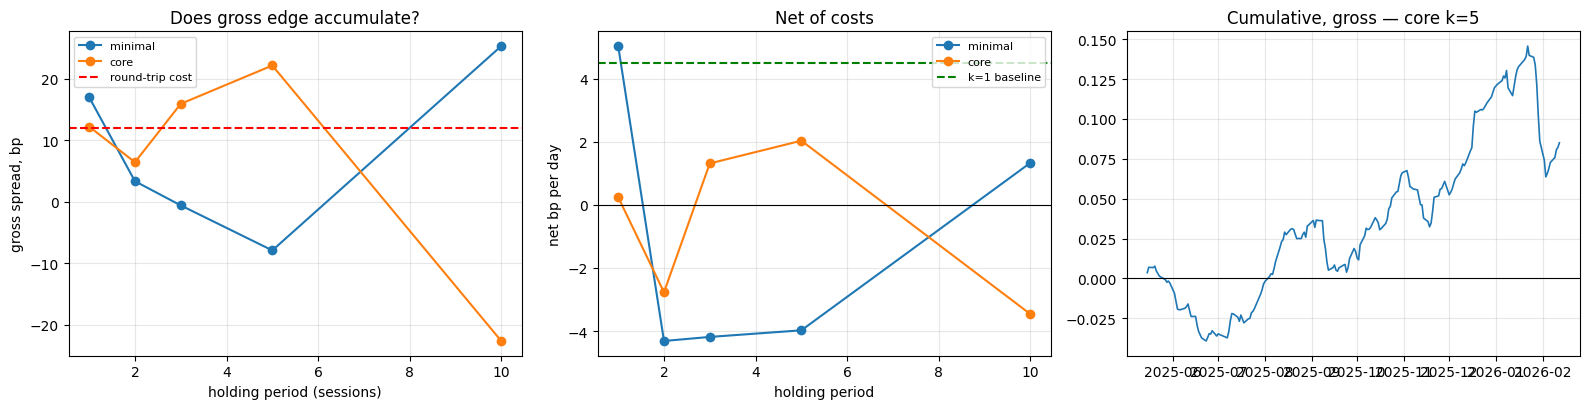

wrote h1_horizon_sweep_20260823.csv and h1_decay_20260823.csv


In [8]:
# ============================ Cell 8 — Charts and export
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

ks = sorted(set(table["k"]))
for nm in FEATURES:
    sub = table[table.index.str.startswith(nm)]
    ax[0].plot(sub["k"], sub["gross_bp_total"], "o-", label=nm)
ax[0].axhline(CFG["round_trip_bp"], color="red", ls="--", label="round-trip cost")
ax[0].set_xlabel("holding period (sessions)"); ax[0].set_ylabel("gross spread, bp")
ax[0].set_title("Does gross edge accumulate?"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

for nm in FEATURES:
    sub = table[table.index.str.startswith(nm)]
    ax[1].plot(sub["k"], sub["NET_bp_per_day"], "o-", label=nm)
ax[1].axhline(4.5, color="green", ls="--", label="k=1 baseline")
ax[1].axhline(0, color="black", lw=.8)
ax[1].set_xlabel("holding period"); ax[1].set_ylabel("net bp per day")
ax[1].set_title("Net of costs"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].plot(bd["session"], (bd["ls"].fillna(0)/bk + 1).cumprod() - 1, lw=1.2)
ax[2].axhline(0, color="black", lw=.8)
ax[2].set_title(f"Cumulative, gross — {best}"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

stamp = pd.Timestamp.today().strftime("%Y%m%d")
table.to_csv(f"h1_horizon_sweep_{stamp}.csv")
decay.to_csv(f"h1_decay_{stamp}.csv")
print(f"wrote h1_horizon_sweep_{stamp}.csv and h1_decay_{stamp}.csv")